# Linha de Visada, Reflexão e Difração

Neste notebook, você irá:

* Aprender o que é difração e por que ela é importante;
* Realizar diversos experimentos de ray tracing para validar alguns resultados teóricos;
* Familiarizar-se com a API do Sionna RT;
* Visualizar o impacto da difração nas respostas ao impulso do canal e nos mapas de cobertura.

## Pequena revisão

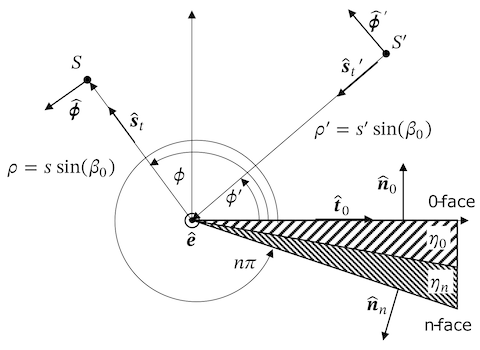


Vamos considerar uma cunha infinitamente longa, conforme mostrado na figura acima. Para visualizar melhor essa situação, imagine uma fatia de pizza que se estende infinitamente.

O vetor da aresta aponta diretamente para fora da tela, e a cunha possui um ângulo de abertura de $n\pi$, onde $n$ é um número real entre 1 e 2.

A cunha possui duas faces, a face 0 e a face $n$. Elas são identificadas dessa maneira para indicar a partir de qual superfície o ângulo $\phi'\in[0,n]$ de uma onda eletromagnética incidente localmente plana é medido. As duas faces podem ser feitas de materiais diferentes, cada um com suas próprias propriedades. Essas propriedades são representadas por um termo conhecido como **permissividade relativa complexa**, denotada por $\eta_0$ e $\eta_n$, respectivamente. Sem entrar muito profundamente nos detalhes, a permissividade mede como um material reage à aplicação de um campo elétrico.

Podemos definir três regiões distintas nessa figura: a **Região I**, na qual estão presentes tanto o campo incidente quanto o campo refletido pela face 0; a **Região II**, na qual o campo refletido desaparece; e a **Região III**, na qual o campo incidente é bloqueado pela cunha. As três regiões são separadas pela **fronteira de sombra da reflexão** (*Reflection Shadow Boundary — RSB*) e pela **fronteira de sombra da incidência** (*Incident Shadow Boundary — ISB*).

A primeira é determinada pelo ângulo de reflexão especular $\pi-\phi'$, enquanto a segunda é simplesmente a continuação da direção da onda incidente através da aresta, ou seja, $\pi+\phi'$.

Utilizando apenas a **óptica geométrica (GO)**, o campo eletromagnético sofreria uma mudança abrupta em cada fronteira, pois as componentes do campo refletido e incidente desapareceriam repentinamente. Como isso não é fisicamente plausível, a **teoria geométrica da difração (GTD)** [1], desenvolvida por Joseph B. Keller na década de 1960, introduz um chamado **campo difratado**, que garante que o campo total seja contínuo.

O campo difratado é, portanto, especialmente importante nas regiões de transição entre as diferentes regiões e, em seguida, decai rapidamente até zero. Mais importante ainda, **sem difração, não haveria campo além da ISB na Região III**.

A difração é, portanto, um fenômeno muito importante, pois possibilita a existência de cobertura sem fio atrás de edifícios, em posições que não possuem linha de visada (*line-of-sight*) por meio de um caminho refletido forte. Como você verá mais adiante neste tutorial, o campo difratado é, em geral, muito mais fraco que o campo incidente ou refletido. Além disso, quanto maior a frequência, mais rapidamente o campo difratado decai à medida que nos afastamos da RSB e da ISB.


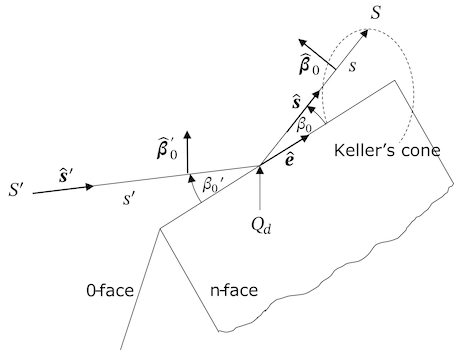


De acordo com a **GTD**, quando um raio atinge um ponto da aresta, sua energia é distribuída por um contínuo de raios que se encontram sobre o **cone de Keller**. Todos os raios desse cone formam ângulos iguais com a aresta de difração no ponto de difração, ou seja, $\beta_0'=\beta_0$.

Pode-se interpretar esse fenômeno como uma extensão da **lei da reflexão** em superfícies planas. As figuras acima ilustram esse conceito.

A GTD foi posteriormente estendida para a **teoria uniforme da difração (UTD — Uniform Theory of Diffraction)** [2,3], que supera algumas de suas limitações.

Neste notebook, exploraremos esses efeitos em detalhes e, como consequência, também validaremos a implementação da UTD no **Sionna RT**.

### Cunha vs. Aresta

Primeiramente, é importante entender a diferença entre uma *wedge* (**cunha**) e uma *edge* (**aresta**), e por que fazemos essa distinção.

O Sionna define uma *wedge* como o **segmento de reta entre duas primitivas**, ou seja, o segmento comum a dois triângulos. Por exemplo, um edifício cúbico teria **12 cunhas**.

Para primitivas que possuem um ou mais segmentos de reta que **não são compartilhados com outra primitiva**, o Sionna se refere a esses segmentos de reta como *edges* (**arestas**). Veja [`sionna.rt.scene.floor_wall`](https://jhoydis.github.io/sionna-0.19.2-doc/api/rt.html#sionna.rt.scene.floor_wall) como exemplo de uma cena.

Por padrão, o Sionna **não simula a difração em arestas** (`edge_diffraction=False`), para evitar problemas como a difração nas arestas externas da superfície do solo (modelada como um plano retangular).


## Configuração e imports <a class="anchor" id="GPU-Configuration-and-Imports"></a>

In [1]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    # Only auto-install when the package itself is missing, not when a
    # transitive dependency fails to import.
    if getattr(e, "name", None) not in ("sionna", "sionna.rt"):
        raise
    import os
    import sys
    if "google.colab" in sys.modules:
        # Install Sionna RT in Google Colab
        print("Installing Sionna RT and restarting the runtime. Please run the cell again.")
        os.system("pip install sionna-rt")
        os.kill(os.getpid(), 5)
    else:
        raise e

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import drjit as dr
import mitsuba as mi

no_preview = True # Toggle to False to use the preview widget
   
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, ITURadioMaterial,\
    Camera, PathSolver, InteractionType, RadioMapSolver
from sionna.rt.utils import r_hat

## Experimentos com uma cunha

Começamos importando uma cena já pronto do Sionna RT que contém apenas uma cunha:

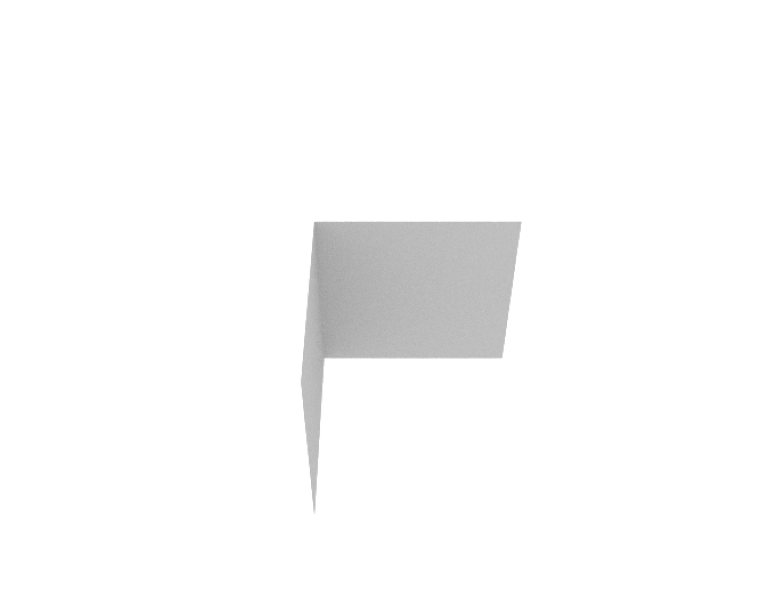

In [2]:
scene = load_scene(sionna.rt.scene.simple_wedge, merge_shapes=False)

if no_preview:
    # Render scene
    my_cam = Camera(position=[10,-100,100], look_at=[10,0,0])
    scene.render(camera=my_cam);

In [3]:
if not no_preview:
    scene.preview();

A cunha possui um ângulo de abertura de $\frac{3}{2}\pi=270^\circ$, ou seja, $n=1{,}5$. A face 0 está alinhada com o eixo $x$, enquanto a face $n$ está alinhada com o eixo $y$ negativo.

Para os experimentos a seguir, configuraremos a cunha para ser feita de **metal**, um condutor quase perfeito, e definiremos a frequência como **1 GHz**.

In [4]:
scene.frequency = 1e9 # 1GHz
scene.objects["wedge"].radio_material = ITURadioMaterial("metal", itu_type="metal", thickness=100)

Com a nossa cena configurada, agora precisamos configurar um transmissor e posicionar vários receptores para medir o campo.

Vamos assumir que o transmissor e todos os receptores possuem uma única antena isotrópica com polarização vertical.

In [5]:
# Configure the antenna arrays used by the transmitters and receivers
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

scene.rx_array = scene.tx_array

Em seguida, $1000$ transmissores são posicionados ao redor da cunha para estudarmos a distribuição de potência espacialmente.

In [6]:
# Transmitter
tx_angle = 30/180*dr.pi # Angle phi from the 0-face
tx_dist = 50 # Distance from the edge
tx_pos = tx_dist*r_hat(dr.pi/2, tx_angle)
ref_boundary = (dr.pi - tx_angle)/dr.pi*180
los_boundary = (dr.pi + tx_angle)/dr.pi*180
scene.add(Transmitter(name="tx",
                      position=tx_pos,
                      orientation=[0,0,0]))

# Receivers
# We place num_rx receivers uniformly spaced on the segment of a circle around the wedge
num_rx = 1000 # Number of receivers
rx_dist = 5 # Distance from the edge
phi = dr.linspace(mi.Float, 1e-2, 3/2*dr.pi-1e-2, num=num_rx)
theta = dr.pi/2*dr.ones(mi.Float, num_rx)
rx_pos = rx_dist*r_hat(theta, phi)

for i in range(num_rx):
    scene.add(Receiver(name=f"rx-{i}",
                       position=[rx_pos.x[i], rx_pos.y[i], rx_pos.z[i]],
                       orientation=[0,0,0]))

In [7]:
if not no_preview:
    scene.preview()

Em seguida, computamos a resposta ao impulso do canal entre o transmissor e todos os receptores.

In [8]:
# Compute paths between the transmitter and all receivers
paths = PathSolver()(scene,
                     max_depth=1,
                     los=True,
                     specular_reflection=True,
                     diffraction=True,
                     edge_diffraction=False,
                     refraction=False,
                     diffuse_reflection=False)

# Obtain channel impulse responses
# We squeeze irrelevant dimensions
# [num_rx, max_num_paths]
a, tau = [np.squeeze(t) for t in paths.cir(out_type="numpy")]

Na figura abaixo, a **esfera vermelha** representa o transmissor, e o **círculo verde** corresponde aos **1000 receptores**, distribuídos uniformemente ao longo de um segmento de uma circunferência ao redor da aresta.

Em seguida, calculamos a **resposta ao impulso do canal** entre o transmissor e todos os receptores. Neste notebook, desativamos o **espalhamento** (*scattering*).

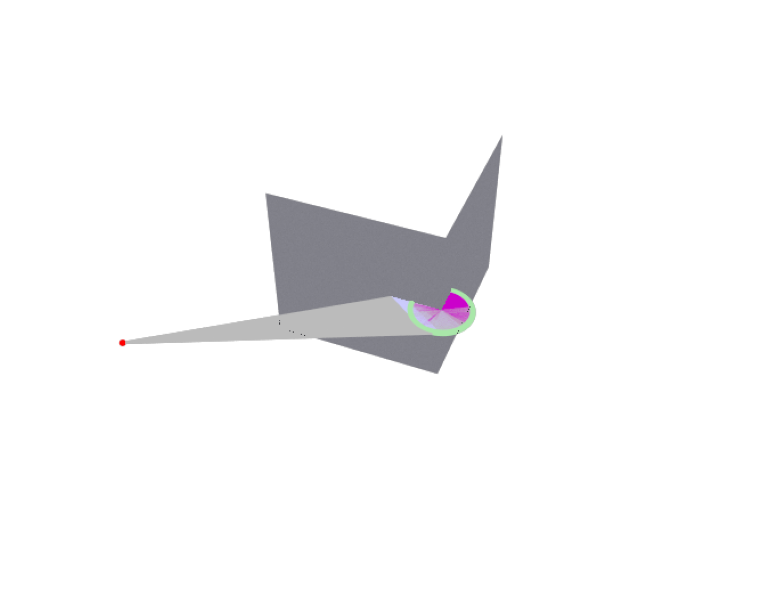

In [9]:
# Render scene
my_cam.position = [-30,100,100]
my_cam.look_at([10,0,0])
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=20);

Vamos olhar a resposta ao impulso do canal para um receptor:

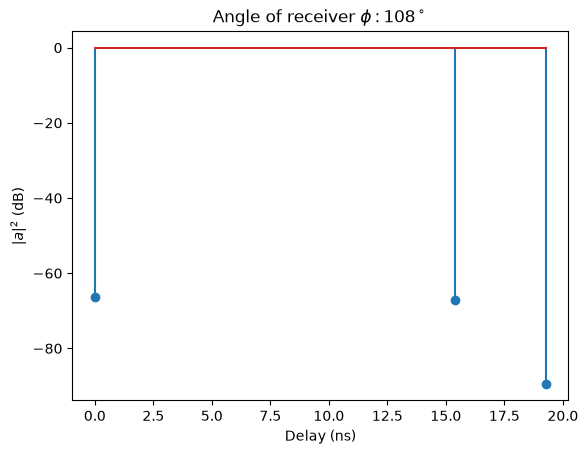

In [10]:
n = 400
plt.figure()
plt.stem(tau[n]/1e-9, 10*np.log10(np.abs(a[n])**2))
plt.title(fr"Angle of receiver $\phi: {int(phi[n]/dr.pi*180)}^\circ$");
plt.xlabel("Delay (ns)");
plt.ylabel("$|a|^2$ (dB)");

Para um ângulo de aproximadamente **108 graus**, o receptor está localizado dentro da **Região I**, onde todos os efeitos de propagação devem estar presentes.

Como esperado, podemos observar **três caminhos de propagação**: **linha de visada**, **refletido** e **difratado**. Enquanto os dois primeiros possuem aproximadamente a mesma intensidade (pois o metal é um refletor quase perfeito), o caminho difratado possui uma energia significativamente menor.

Em seguida, vamos calcular a **resposta em frequência do canal** $H(f)$ como a soma de todos os caminhos multiplicados por seus respectivos **fatores de fase complexos**:

$$H(f) = \sum_{i=1}^N a_i e^{-j2\pi\tau_i f}$$

In [11]:
h_f_tot = np.sum(a, axis=-1)

Agora podemos visualizar o ganhor de percurso $|H(f)|^2$ para todos os receptores como função do ângulo $\phi$:

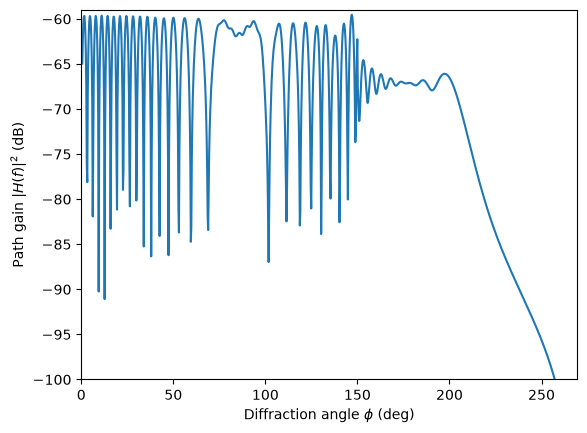

In [12]:
fig = plt.figure()
plt.plot(phi.numpy()/dr.pi*180, 20*np.log10(np.abs(h_f_tot)))
plt.xlabel(r"Diffraction angle $\phi$ (deg)");
plt.ylabel(r"Path gain $|H(f)|^2$ (dB)");
plt.ylim([-100, -59]);
plt.xlim([0, phi[-1]/dr.pi*180]);

A observação mais importante da figura acima é que $H(f)$ permanece **contínuo** ao longo de todo o intervalo de $\phi$, especialmente nas fronteiras RSB e ISB, localizadas aproximadamente em $\phi=150^\circ$ e $\phi=209^\circ$, respectivamente.

Para obter uma compreensão mais detalhada, a **função auxiliar** na célula seguinte calcula e visualiza os diferentes componentes de $H(f)$ de acordo com seu tipo.

In [13]:
def plot(frequency, material):
    """Plots the path gain $|H(f)|^2 versus $phi$ for a given
       frequency and RadioMaterial of the wedge.
    """
    # Set carrier frequency and material of the wedge
    # You can see a list of available materials by executing
    # scene.radio_materials
    scene.frequency = frequency
    used_material = scene.get(material)
    if used_material is None:
        scene.objects["wedge"].radio_material = ITURadioMaterial(material, itu_type=material, thickness=100)
    else:
        scene.objects["wedge"].radio_material = used_material

    # Recompute paths with the updated material and frequency
    paths = PathSolver()(scene,
                         max_depth=1,
                         los=True,
                         specular_reflection=True,
                         diffraction=True,
                         edge_diffraction=False,
                         refraction=False,
                         diffuse_reflection=False)
    a, _ = paths.cir(out_type="numpy")
    a = np.squeeze(a)
    
    # Separate LoS, reflected, and diffracted paths
    interactions = np.squeeze(paths.interactions.numpy())
    valid = np.squeeze(paths.valid.numpy())
    a_los = []
    a_reflected = []
    a_diffracted = []
    for i in range(num_rx):
        # LoS
        los_index = np.where(np.logical_and(valid[i], interactions[i] == InteractionType.NONE))[0]
        if los_index.shape[0] == 0:
            a_los.append(0.)
        else:
            a_los.append(a[i][los_index][0])
        # Reflection
        ref_index = np.where(np.logical_and(valid[i], interactions[i] == InteractionType.SPECULAR))[0]
        if ref_index.shape[0] == 0:
            a_reflected.append(0.)
        else:
            a_reflected.append(a[i][ref_index][0])
        # Diffraction
        dif_index = np.where(np.logical_and(valid[i], interactions[i] == InteractionType.DIFFRACTION))[0]
        if dif_index.shape[0] == 0:
            a_diffracted.append(0.)
        else:
            a_diffracted.append(a[i][dif_index][0])
    a_los = np.array(a_los)
    a_reflected = np.array(a_reflected)
    a_diffracted = np.array(a_diffracted)

    def compute_gain(a):
        """Compute $|H(f)|^2 are f = 0 where H(f) is the baseband channel frequency response"""
        if len(a.shape) == 2:
                h_f_2 = np.abs(np.sum(a, axis=-1))**2

        else:
                h_f_2 = np.abs(a)**2
        h_f_2 = np.where(h_f_2==0, 1e-24, h_f_2)
        g_db = 10*np.log10(h_f_2)
        return np.squeeze(g_db)

    # Compute gain for all path types
    g_tot_db = compute_gain(a)
    g_los_db = compute_gain(a_los)
    g_ref_db = compute_gain(a_reflected)
    g_dif_db = compute_gain(a_diffracted)

    # Make a nice plot
    fig = plt.figure()
    phi_deg = phi.numpy()/np.pi*180
    ymax = np.max(g_tot_db)+5
    ymin = ymax - 45
    plt.plot(phi_deg, g_tot_db)
    plt.plot(phi_deg, g_los_db)
    plt.plot(phi_deg, g_ref_db)
    plt.plot(phi_deg, g_dif_db)
    plt.ylim([ymin, ymax])
    plt.xlim([phi_deg[0], phi_deg[-1]]);
    plt.legend(["Total", "LoS", "Reflected", "Diffracted"], loc="lower left")
    plt.xlabel(r"Diffraction angle $\phi$ (deg)")
    plt.ylabel(r"Path gain $|H(f)|^2$ (dB)")
    ax = fig.axes[0]
    ax.axvline(x=ref_boundary, ymin=0, ymax=1, color="black", linestyle="--")
    ax.axvline(x=los_boundary, ymin=0, ymax=1, color="black", linestyle="--")
    ax.text(ref_boundary-10,ymin+5,'RSB',rotation=90,va='top')
    ax.text(los_boundary-10,ymin+5,'ISB',rotation=90,va='top')
    ax.text(ref_boundary/2,ymax-2.5,'Region I', ha='center', va='center',
            bbox=dict(facecolor='none', edgecolor='black', pad=4.0))
    ax.text(los_boundary-(los_boundary-ref_boundary)/2,ymax-2.5,'Region II', ha='center', va='center',
            bbox=dict(facecolor='none', edgecolor='black', pad=4.0))
    ax.text(phi_deg[-1]-(phi_deg[-1]-los_boundary)/2,ymax-2.5,'Region III', ha='center', va='center',
            bbox=dict(facecolor='none', edgecolor='black', pad=4.0))
    plt.title('$f={}$ GHz ("{}")'.format(frequency/1e9, material))
    plt.tight_layout()
    return fig

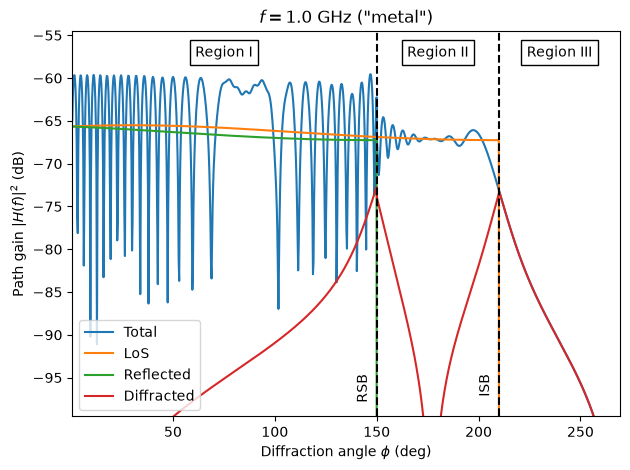

In [14]:
plot(1e9, "metal");

Percebemos imediatamente que a madeira é um mau refletor, pois a intensidade do caminho refletido diminuiu em $10$ dB em comparação com o metal. Graças à extensão heurística das equações do campo difratado em [2] para condutores não perfeitos, apresentada em [4] (e implementada no Sionna RT), o campo total permanece contínuo.

Agora, você pode experimentar diferentes materiais e frequências por conta própria.

## Mapas de cobertura com difração

Até agora, obtivemos uma compreensão microscópica sólida do efeito da dispersão. Vamos agora passar aos efeitos macroscópicos, que podem ser observados de maneira bastante clara por meio dos mapas de cobertura.

Um mapa de cobertura descreve a potência média recebida de um transmissor específico em cada ponto de um plano. Os efeitos do desvanecimento rápido (*fast fading*), ou seja, a interferência construtiva/destrutiva entre diferentes caminhos, são eliminados ao somarmos os quadrados das amplitudes de todos os caminhos. Como não podemos calcular mapas de cobertura com uma resolução infinitamente fina, eles são aproximados por pequenos elementos retangulares, para os quais são calculados valores médios. Para uma explicação detalhada, consulte a [Documentação da API](https://nvlabs.github.io/sionna/rt/api/radio_map_solvers.html).

Vamos agora carregar uma cena um pouco mais interessante, contendo alguns edifícios retangulares, e adicionar um transmissor. Observe que não precisamos adicionar nenhum receptor para calcular um mapa de cobertura.

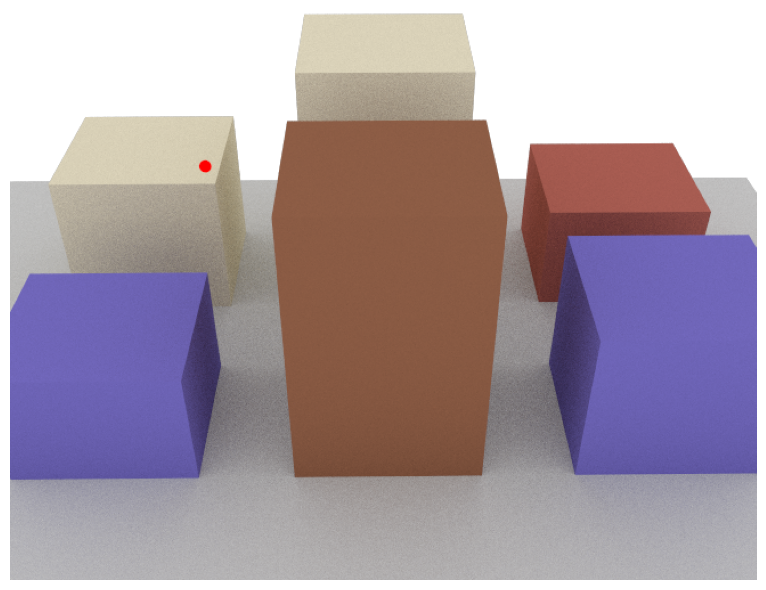

In [15]:
scene = load_scene(sionna.rt.scene.simple_street_canyon, merge_shapes=True)

# Set the carrier frequency to 1GHz
scene.frequency = 1e9

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

scene.rx_array = scene.tx_array

scene.add(Transmitter(name="tx",
                      position=[-33,11,32],
                      orientation=[0,0,0]))

# Render scene
my_cam = Camera([-1.5,-137,115])
my_cam.look_at([0,0,10])
if no_preview:
    scene.render(camera=my_cam);

In [16]:
if not no_preview:
    scene.preview();

Computar um mapa de cobertura é feito simplesmente rodando o comando seguinte:

In [17]:
radio_map_solver = RadioMapSolver()
cm = radio_map_solver(scene, cell_size=(1, 1), samples_per_tx=10**7,
                      refraction=False) # Deactivate refraction

Visualizamos o mapa de cobertura da seguinte forma:

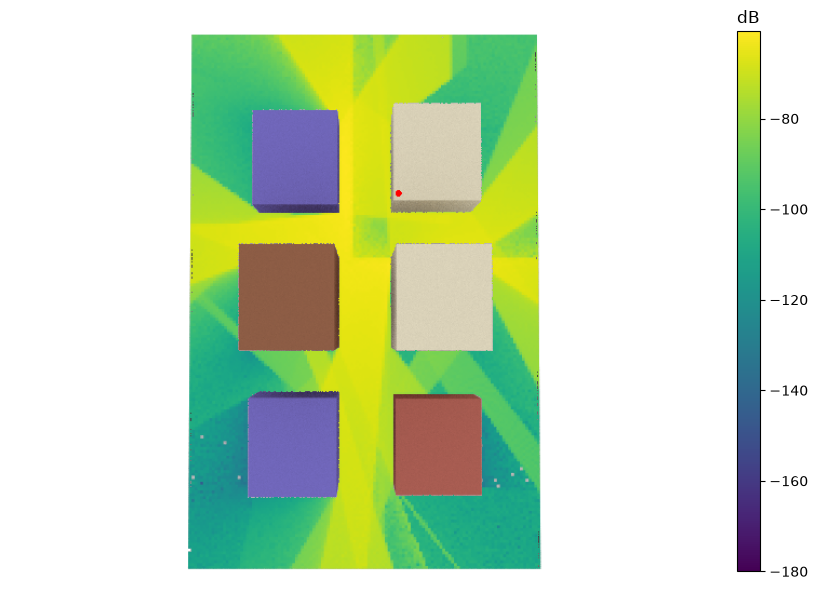

In [18]:
cm = radio_map_solver(scene, cell_size=(1, 1), samples_per_tx=10**7,
                      los=True,
                      specular_reflection=True,
                      refraction=False, # Deactivate refraction
                      diffraction=True) # Activate diffraction

my_cam = Camera(position=[10,0,300], look_at=[0,0,0])
my_cam.look_at([0,0,0])

# Render scene with the new camera and overlay the coverage map
scene.render(camera=my_cam, radio_map=cm, rm_show_color_bar=True, rm_vmin=-180);

## References
[1] J.B. Keller, [Geometrical Theory of Diffraction](https://opg.optica.org/josa/abstract.cfm?uri=josa-52-2-116), Journal of the Optical Society of America, vol. 52, no. 2, Feb. 1962.

[2] R.G. Kouyoumjian, [A uniform geometrical theory of diffraction for an edge in a perfectly conducting surface](https://ieeexplore.ieee.org/abstract/document/1451581/authors#authors), Proc. of the IEEE, vol. 62, no. 11, Nov. 1974.

[3] D.A. McNamara, C.W.I. Pistorius, J.A.G. Malherbe, [Introduction to the Uniform Geometrical Theory of Diffraction](https://us.artechhouse.com/Introduction-to-the-Uniform-Geometrical-Theory-of-Diffraction-P288.aspx), Artech House, 1990.

[4] R. Luebbers, [Finite conductivity uniform GTD versus knife edge diffraction in prediction of propagation path loss](https://ieeexplore.ieee.org/abstract/document/1143189), IEEE Trans. Antennas and Propagation, vol. 32, no. 1, Jan. 1984.